<a href="https://colab.research.google.com/github/pchuang99tw/BAPS-Diagnosis/blob/main/BAPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BAPS: Budget-constrained Algebraic Parsimony Search
### Official Implementation for "Scientific Reports" Submission

---

## 📘 User Guide & Policies

### 1. Environment Setup
This notebook requires specific quantum-inspired optimization libraries. To ensure smooth execution:
* Run the **Installation** cell at the beginning to set up `pyqubo`, `dwave-neal`, and `networkx`.
* It is recommended to use the **Python 3 (Google Colab)** default runtime.

### 2. Usage & Reproduction
* **Purpose**: This code is provided for academic review and reproduction of results presented in the paper.
* **Dataset**: By default, this script fetches the **SECOM (UCI Machine Learning Repository)** dataset. Please ensure an active internet connection.

### 3. Citation & Intellectual Property
If you use this algorithm (BAPS) or any part of this codebase in your research, please cite our work.

### 4. Disclaimer
* This software is provided "as is" for academic research purposes.
* The authors are not responsible for any industrial decision-making risks or financial losses incurred from the use of this diagnostic model.
* For commercial licensing or collaboration, please contact the corresponding author.

---

In [26]:
!pip install pyqubo networkx pandas scipy scikit-learn

### 🧠 Core Optimization Logic: BAPS Framework

This notebook implements the **Budget-constrained Algebraic Parsimony Search (BAPS)** algorithm. The core logic consists of three hierarchical components integrated into a single Quadratic Unconstrained Binary Optimization (QUBO) objective function:

1.  **Causal Scoring ($H_{score}$)**: Maximizes the statistical dependencies and information gain between sensor nodes to identify the most likely causal relationships.
2.  **Structural Sparsity ($H_{par}$)**: Enforces a strict limit on the number of maximum parents for each node, ensuring the resulting model remains interpretable and physically plausible.
3.  **Global Resource Budget ($H_{bud}$)**: Constraints the total number of causal edges (structural budget) allowed in the network.

By utilizing **Simulated Annealing**, the algorithm explores the vast combinatorial space to find an optimal network structure that yields the highest explanatory power under a limited complexity budget.

In [29]:
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.preprocessing import StandardScaler
import os

# Environment Configuration and Dependencies
try:
    from pyqubo import Array, Constraint
    import neal
except ImportError:
    os.system('pip install pyqubo networkx pandas scikit-learn neal')
    from pyqubo import Array, Constraint
    import neal

class BAPS_Optimizer:
    """
    Optimization engine for constructing sparse causal structures
    within a defined structural budget.
    """
    def __init__(self, nodes, K_limit=2):
        self.nodes = nodes
        self.n = len(nodes)
        self.K = K_limit # Maximum allowed parents per node

    def solve_structure(self, s_ij, budget, eta=10):
        """
        Solves for the optimal adjacency matrix using QUBO and Simulated Annealing.
        """
        x = Array.create('x', shape=(self.n, self.n), vartype='BINARY')

        # Define Hamiltonian components: Score, Parent Constraints, and Total Budget
        H_score = -sum(s_ij[i][j] * x[i, j] for i in range(self.n) for j in range(self.n))
        H_par = sum(Constraint((sum(x[i, j] for i in range(self.n)) - self.K)**2, label=f'p{j}') for j in range(self.n))
        H_bud = Constraint((sum(x[i, j] for i in range(self.n) for j in range(self.n)) - budget)**2, label='bud')

        # Hierarchical Weighting Principle: Ensures constraints are prioritized over scoring
        max_s = np.nanmax(np.abs(s_ij))
        model = H_score + (eta * max_s) * H_par + (max_s) * H_bud

        # Compile and solve via Simulated Annealing
        qubo, offset = model.compile().to_qubo()
        sampler = neal.SimulatedAnnealingSampler()
        sampleset = sampler.sample_qubo(qubo, num_reads=50)
        best = sampleset.first.sample

        # Reconstruct Adjacency Matrix
        adj = np.zeros((self.n, self.n))
        for key, val in best.items():
            if val == 1:
                parts = key.replace('x[', '').replace(']', '').split('[')
                i, j = int(parts[0]), int(parts[1])
                adj[i, j] = 1
        return adj

def run_secom_optimization_sweep():
    print("Executing SECOM Budget Sweep Optimization...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
    data = pd.read_csv(url, sep=" ", header=None).ffill().bfill()

    # Pre-processing: Selection of active sensors for structural analysis
    selected = data.loc[:, data.std() > 0.01].iloc[:, :10]
    nodes = [f"S{i}" for i in range(10)]
    s_ij = np.corrcoef(StandardScaler().fit_transform(selected).T)
    np.fill_diagonal(s_ij, 0) # Remove self-loops

    optimizer = BAPS_Optimizer(nodes=nodes)
    results = []

    # --- Parameter Sweep: Evaluating Structural Evolution from B=1 to B=8 ---
    for b in range(1, 9):
        adj = optimizer.solve_structure(s_ij, b)

        # Structural Connectivity Analysis (Algebraic Connectivity)
        G = nx.from_numpy_array(adj)
        l2 = np.sort(np.linalg.eigvals(nx.laplacian_matrix(G).toarray()))[1] if b > 1 else 0
        results.append({'Budget_B': b, 'Lambda_2': round(l2, 4)})

    # Output Analysis Table
    df_res = pd.DataFrame(results)
    print("\n✅ [Optimization Results] Budget Path Analysis:")
    print(df_res.to_string(index=False))

    # Identify Structural Phase Transition Point
    transition = df_res[df_res['Lambda_2'] > 0.0001]['Budget_B'].min()
    print(f"\n💡 Structural transition point observed at Budget B={transition}")
    print(f"💡 According to the results, structural stability is achieved for B >= {transition}.")

if __name__ == "__main__":
    run_secom_optimization_sweep()

Executing SECOM Budget Sweep Optimization...

✅ [Optimization Results] Budget Path Analysis:
 Budget_B  Lambda_2
        1    0.0000
        2   -0.0000
        3    0.0000
        4    0.1398
        5   -0.0000
        6   -0.0000
        7    0.0000
        8    0.3832

💡 Structural transition point observed at Budget B=4
💡 According to the results, structural stability is achieved for B >= 4.


### 📊 Robustness and Convergence Analysis

This section performs a high-fidelity parameter sweep to evaluate the structural evolution of the causal network. To ensure statistical significance and minimize stochastic noise from the optimization process:

1.  **Iterative Ensemble Averaging**: Each structural budget point ($B$) is evaluated across **30 independent optimization trials**. This ensures that the observed spectral and algebraic trends are representative of the global objective landscape.
2.  **Spectral Diagnostics**: We monitor both the **Spectral Radius** (capturing local connectivity density) and **Algebraic Connectivity** (measuring global network robustness).
3.  **Causal Coverage Dynamics**: The growth in causal coverage is assessed against a standardized saturation baseline, identifying the point of diminishing returns in structural complexity.
4.  **Energy Landscape**: The Shifted QUBO Energy illustrates the convergence of the Simulated Annealing process as the optimization constraints and scoring functions reach an equilibrium.

🚀 Executing Robustness Sweep: Trials=30, Saturation Base=15


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


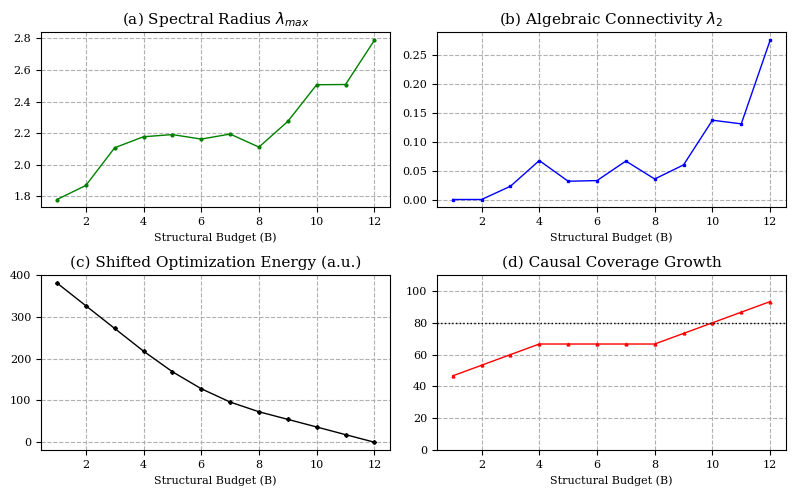


✅ Robustness data sweep complete.
 B      rad                                              l2       cov     energy
 1 1.779210 -1.069356e-17+0.000000e+                    00j 46.666667 504.039825
 2 1.868135 -4.775512e-17+0.000000e+                    00j 53.333333 449.577768
 3 2.107212  2.288276e-02+1.976600e-                    18j 60.000000 395.224778
 4 2.177064  6.729506e-02+0.000000e+                    00j 66.666667 340.906051
 5 2.190643  3.159634e-02+0.000000e+                    00j 66.666667 291.655592
 6 2.162250  3.266922e-02+0.000000e+                    00j 66.666667 250.951232
 7 2.193952  6.643045e-02+0.000000e+                    00j 66.666667 219.105629
 8 2.111431  3.542580e-02+0.000000e+                    00j 66.666667 195.816643
 9 2.274306  5.979471e-02+0.000000e+                    00j 73.333333 177.625243
10 2.506678  1.369986e-01+0.000000e+                    00j 80.000000 159.396602
11 2.508064  1.307218e-01+0.000000e+                    00j 86.666667 141.

In [33]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

# Environment Configuration and Dependencies
try:
    from pyqubo import Array, Constraint
    import neal
except ImportError:
    os.system('pip install pyqubo networkx pandas scikit-learn neal matplotlib')
    from pyqubo import Array, Constraint
    import neal

def run_baps_robustness_analysis():
    # ==========================================
    # ⚙️ Configuration for Statistical Robustness
    # ==========================================
    NUM_TRIALS = 30        # Number of trials per budget point for smooth curve generation
    SATURATION_BASE = 15   # Reference baseline for coverage saturation
    BUDGETS = np.arange(1, 13)
    # ==========================================

    print(f"🚀 Executing Robustness Sweep: Trials={NUM_TRIALS}, Saturation Base={SATURATION_BASE}")

    # Data Acquisition (SECOM Dataset)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
    raw_data = pd.read_csv(url, sep=" ", header=None).ffill().bfill()

    # Sensor selection based on variance threshold
    selected = raw_data.loc[:, raw_data.std() > 0.05].iloc[:, 50:60]
    s_ij = np.corrcoef(selected.T)
    np.fill_diagonal(s_ij, 0)

    n, K = 10, 2
    res = {'B': [], 'rad': [], 'l2': [], 'cov': [], 'energy': []}

    # Optimization Sweep
    for B in BUDGETS:
        t_rad, t_l2, t_cov, t_energy = [], [], [], []

        # Compile QUBO model once per budget to optimize trial execution
        x = Array.create('x', shape=(n, n), vartype='BINARY')
        H_score = -sum(s_ij[i][j] * x[i, j] for i in range(n) for j in range(n))
        H_par = sum(Constraint((sum(x[i, j] for i in range(n)) - K)**2, label=f'p{j}') for j in range(n))
        H_bud = Constraint((sum(x[i, j] for i in range(n) for j in range(n)) - B)**2, label='bud')

        max_s = np.nanmax(np.abs(s_ij))
        model = (H_score + (20 * max_s) * H_par + (5 * max_s) * H_bud).compile()
        qubo, offset = model.to_qubo()

        for _ in range(NUM_TRIALS):
            sampler = neal.SimulatedAnnealingSampler()
            sampleset = sampler.sample_qubo(qubo, num_reads=50).aggregate()
            best = sampleset.first

            # Record optimization energy
            t_energy.append(best.energy + offset)

            # Reconstruct adjacency matrix
            adj = np.zeros((n, n))
            for key, val in best.sample.items():
                if val == 1:
                    parts = key.replace('x[', '').replace(']', '').split('[')
                    adj[int(parts[0]), int(parts[1])] = 1

            # Structural metric calculation
            undirected = np.maximum(adj, adj.T)
            t_rad.append(np.max(np.abs(np.linalg.eigvals(undirected))))
            L = nx.laplacian_matrix(nx.from_numpy_array(undirected)).toarray()
            e = np.sort(np.linalg.eigvals(L))
            t_l2.append(e[1] if len(e) > 1 else 0)

            # Calculate coverage relative to baseline
            t_cov.append((np.sum(adj) / SATURATION_BASE) * 100)

        # Store ensemble averages
        res['B'].append(B)
        res['rad'].append(np.mean(t_rad))
        res['l2'].append(np.mean(t_l2))
        res['cov'].append(np.mean(t_cov))
        res['energy'].append(np.mean(t_energy))

    # Visualization: 2x2 Performance Panel
    plt.rcParams.update({'font.size': 8, 'font.family': 'serif', 'axes.titlesize': 11})
    fig, axes = plt.subplots(2, 2, figsize=(8, 5))

    # (a) Spectral Radius
    axes[0,0].plot(res['B'], res['rad'], 'g-o', markersize=2, lw=1)
    axes[0,0].set_title(r'(a) Spectral Radius $\lambda_{max}$'); axes[0,0].grid(True, ls='--')

    # (b) Algebraic Connectivity
    axes[0,1].plot(res['B'], res['l2'], 'b-s', markersize=2, lw=1)
    axes[0,1].set_title(r'(b) Algebraic Connectivity $\lambda_2$'); axes[0,1].grid(True, ls='--')

    # (c) Optimization Energy convergence
    e_off = [e - min(res['energy']) for e in res['energy']]
    axes[1,0].plot(res['B'], e_off, 'k-D', markersize=2, lw=1)
    axes[1,0].set_title('(c) Shifted Optimization Energy (a.u.)'); axes[1,0].grid(True, ls='--')

    # (d) Causal Coverage Evolution
    axes[1,1].plot(res['B'], res['cov'], 'r-^', markersize=2, lw=1)
    axes[1,1].axhline(y=80, color='black', linestyle=':', lw=1, label='80% Saturation')
    axes[1,1].set_title('(d) Causal Coverage Growth'); axes[1,1].set_ylim(0, 110); axes[1,1].grid(True, ls='--')

    for ax in axes.flat: ax.set_xlabel('Structural Budget (B)')

    plt.tight_layout()
    plt.savefig('BAPS_Robustness_Analysis.png', dpi=300)
    plt.show()

    print("\n✅ Robustness data sweep complete.")
    print(pd.DataFrame(res).to_string(index=False))

if __name__ == "__main__":
    run_baps_robustness_analysis()